# HAWQ

## Global Configurations & Imports

In [9]:
!pip install --upgrade pip

In [10]:
!pip install torch transformers torchvision pillow datasets matplotlib

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from datasets import load_dataset
from transformers import AutoImageProcessor, DeiTForImageClassification
import matplotlib.pyplot as plt
import numpy as np
import copy

from analyzer import ViTHAWQAnalyzer
from bit_allocator import HAWQBitAllocator
from quantizer import replace_linear_with_qlinear
from trainer import HAWQTrainer

/Users/admin/Desktop/MMML/Hessian-Based-Mixed-Precision-Quantization/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Executing on: {DEVICE}")

MODEL_CKPT = "facebook/deit-small-patch16-224"
DATASET_NAME = "zh-plus/tiny-imagenet"

#FAST RUN TOGGLES: set to a small integer (32) to test pipeline logic. Set to None for full dataset.
FAST_RUN_NUM_SAMPLES = 16  
BATCH_SIZE = 8
EPOCHS_PER_PHASE = 1

#metrics dictionary to store results across pipelines
results_log = {}

Executing on: mps


## Data Processing & Loaders

In [6]:
print("Loading processor and dataset...")
processor = AutoImageProcessor.from_pretrained(MODEL_CKPT)
dataset = load_dataset(DATASET_NAME)

Loading processor and dataset...


In [7]:
processor, dataset

(ViTImageProcessor {
   "do_normalize": true,
   "do_rescale": true,
   "do_resize": true,
   "image_mean": [
     0.5,
     0.5,
     0.5
   ],
   "image_processor_type": "ViTImageProcessor",
   "image_std": [
     0.5,
     0.5,
     0.5
   ],
   "resample": 2,
   "rescale_factor": 0.00392156862745098,
   "size": {
     "height": 224,
     "width": 224
   }
 },
 DatasetDict({
     train: Dataset({
         features: ['image', 'label'],
         num_rows: 100000
     })
     valid: Dataset({
         features: ['image', 'label'],
         num_rows: 10000
     })
 }))

In [8]:
num_labels = len(dataset.unique("label")["train"])
num_labels

200

In [9]:
def transform(example_batch):
    #handles upscaling and normalization required by DeiT
    inputs = processor([x.convert("RGB") for x in example_batch["image"]], return_tensors="pt")
    inputs["labels"] = example_batch["label"]
    return inputs

In [10]:
processed_dataset = dataset.with_transform(transform)

In [11]:
if FAST_RUN_NUM_SAMPLES is not None:
    train_dataset = Subset(processed_dataset["train"], range(FAST_RUN_NUM_SAMPLES))
    val_dataset = Subset(processed_dataset["valid"], range(FAST_RUN_NUM_SAMPLES))
else:
    train_dataset = processed_dataset["train"]
    val_dataset = processed_dataset["valid"]

In [12]:
def collate_fn(batch):
    pixel_values = torch.stack([item['pixel_values'] for item in batch])
    labels = torch.tensor([item['labels'] for item in batch])
    return pixel_values, labels

In [13]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train batches: 2, Val batches: 2


## Pipeline A (Continuous Upper Bound)

We initialize the model and establish the continuous local minimum

In [14]:
#tiny-ImageNet has 200 classes
model_fp32 = DeiTForImageClassification.from_pretrained(MODEL_CKPT, num_labels=num_labels, ignore_mismatched_sizes=True).to(DEVICE)
criterion = nn.CrossEntropyLoss()

You are using a model of type `vit` to instantiate a model of type `deit`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.
You passed `num_labels=200` which is incompatible to the `id2label` map of length `1000`.
Loading weights: 100%|██████████| 2/2 [00:00<00:00, 14266.34it/s]
DeiTForImageClassification LOAD REPORT from: facebook/deit-small-patch16-224
Key                                                          | Status     |                                                                                            
-------------------------------------------------------------+------------+--------------------------------------------------------------------------------------------
vit.encoder.layer.{0...11}.attention.attention.value.weight  | 

We are utilizing transfer learning. The pre-trained weights for `facebook/deit-small-patch16-224` were mathematically converged on the ImageNet-1K dataset, which has 1,000 distinct classes. Therefore, the final classification layer (the "head") is a weight matrix of shape $[384,1000]$

However, our target dataset, `Tiny-ImageNet`, only possesses 200 classes. When we instantiate the model with $num_labels=200$, PyTorch builds a final classification matrix of shape [384,200].

If we attempt to load the pre-trained state dictionary without this flag, PyTorch will throw a fatal dimension mismatch error because a $384×1000$ tensor cannot map to a $384×200$ tensor.

By setting ignore_mismatched_sizes=True, we instruct the HuggingFace API to safely bypass this specific tensor. It will successfully load the pre-trained weights for the entire feature extractor (all the attention and intermediate blocks) but will discard the $384×1000$ pre-trained classifier. Instead, it will randomly initialize a fresh $384×200$ classifier. 

This is why Pipeline A (full fine-tuning) is strictly necessary: it allows the network to train this new, randomly initialized head while adapting the pre-trained feature extractor to the new dataset.

In [15]:
baseline_trainer = HAWQTrainer(
    model=model_fp32, 
    analyzer=None,
    criterion=criterion, 
    train_dataloader=train_loader, 
    val_dataloader=val_loader,
    device=DEVICE
)

In [16]:
baseline_trainer.unfreeze_module(baseline_trainer.model) #all is trainable
opt = baseline_trainer.build_optimizer()

In [17]:
for epoch in range(EPOCHS_PER_PHASE):
    baseline_trainer.train_one_epoch(opt)

In [18]:
metrics_A = baseline_trainer.evaluate()
print(f"Pipeline A Metrics: {metrics_A}")
results_log["A_FP32"] = {"acc": metrics_A["val_acc"], "avg_bits": 32}

Pipeline A Metrics: {'val_loss': 5.267932176589966, 'val_acc': 0.0}


In [19]:
converged_state_dict = copy.deepcopy(model_fp32.state_dict())

## Pipeline B (Uniform PTQ)

This measures the mathematical shock of projecting the converged weights onto a discrete grid without allowing the optimizer to recover

In [20]:
model_ptq = DeiTForImageClassification.from_pretrained(MODEL_CKPT, num_labels=num_labels, ignore_mismatched_sizes=True).to(DEVICE)
model_ptq.load_state_dict(converged_state_dict)

You are using a model of type `vit` to instantiate a model of type `deit`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.
You passed `num_labels=200` which is incompatible to the `id2label` map of length `1000`.
Loading weights: 100%|██████████| 2/2 [00:00<00:00, 23497.50it/s]
DeiTForImageClassification LOAD REPORT from: facebook/deit-small-patch16-224
Key                                                          | Status     |                                                                                            
-------------------------------------------------------------+------------+--------------------------------------------------------------------------------------------
vit.encoder.layer.{0...11}.attention.attention.value.weight  | 

<All keys matched successfully>

In [21]:
linear_blocks = [name for name, mod in model_ptq.named_modules() if isinstance(mod, nn.Linear)]
replace_linear_with_qlinear(model_ptq, linear_blocks) #replacing Linear layers with QLinear

In [22]:
for name, module in model_ptq.named_modules():
    if hasattr(module, "set_weight_quant"):
        module.set_weight_quant(enabled=True, bit_width=4)
        module.set_act_quant(enabled=True, bit_width=4)

In [23]:
ptq_trainer = HAWQTrainer(model_ptq, None, criterion, train_loader, val_loader, device=DEVICE)

In [24]:
metrics_B = ptq_trainer.evaluate()

In [25]:
print(f"Pipeline B Metrics: {metrics_B}")
results_log["B_PTQ_W4A4"] = {"acc": metrics_B["val_acc"], "avg_bits": 4}

Pipeline B Metrics: {'val_loss': 5.298277854919434, 'val_acc': 1.0}


## Pipeline C (Uniform QAT)

We allow the Straight-Through Estimator (STE) to actively learn and recover from the uniform W4A4 quantization noise.

In [26]:
model_qat = DeiTForImageClassification.from_pretrained(MODEL_CKPT, num_labels=num_labels, ignore_mismatched_sizes=True).to(DEVICE)
model_qat.load_state_dict(copy.deepcopy(converged_state_dict))

You are using a model of type `vit` to instantiate a model of type `deit`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.
You passed `num_labels=200` which is incompatible to the `id2label` map of length `1000`.
Loading weights: 100%|██████████| 2/2 [00:00<00:00, 9653.17it/s]
DeiTForImageClassification LOAD REPORT from: facebook/deit-small-patch16-224
Key                                                          | Status     |                                                                                            
-------------------------------------------------------------+------------+--------------------------------------------------------------------------------------------
vit.encoder.layer.{0...11}.attention.attention.value.weight  | U

<All keys matched successfully>

In [27]:
replace_linear_with_qlinear(model_qat, linear_blocks)

In [28]:
for name, module in model_qat.named_modules():
    if hasattr(module, "set_weight_quant"):
        module.set_weight_quant(enabled=True, bit_width=4)
        module.set_act_quant(enabled=True, bit_width=4)

In [29]:
qat_trainer = HAWQTrainer(model_qat, None, criterion, train_loader, val_loader, device=DEVICE)
qat_trainer.unfreeze_module(qat_trainer.model)
opt_qat = qat_trainer.build_optimizer()

In [30]:
for epoch in range(EPOCHS_PER_PHASE):
    qat_trainer.train_one_epoch(opt_qat)

In [31]:
metrics_C = qat_trainer.evaluate()
print(f"Pipeline C Metrics: {metrics_C}")
results_log["C_QAT_W4A4"] = {"acc": metrics_C["val_acc"], "avg_bits": 4}

Pipeline C Metrics: {'val_loss': 5.359507083892822, 'val_acc': 0.0}


## Pipeline D (Target: HAWQ)

In [32]:
model_hawq = DeiTForImageClassification.from_pretrained(MODEL_CKPT, num_labels=num_labels, ignore_mismatched_sizes=True).to(DEVICE)
model_hawq.load_state_dict(copy.deepcopy(converged_state_dict))

You are using a model of type `vit` to instantiate a model of type `deit`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.
You passed `num_labels=200` which is incompatible to the `id2label` map of length `1000`.
Loading weights: 100%|██████████| 2/2 [00:00<00:00, 14217.98it/s]
DeiTForImageClassification LOAD REPORT from: facebook/deit-small-patch16-224
Key                                                          | Status     |                                                                                            
-------------------------------------------------------------+------------+--------------------------------------------------------------------------------------------
vit.encoder.layer.{0...11}.attention.attention.value.weight  | 

<All keys matched successfully>

In [33]:
analyzer = ViTHAWQAnalyzer(model_hawq, train_loader, criterion)

Using device: mps


In [34]:
target_blocks = analyzer.isolate_blocks()
all_sensitivities = analyzer.compute_layer_sensitivities(target_blocks, num_batches=1)

Isolated 73 linear blocks for Hessian analysis.

Computing sensitivities for 73 layers...
[1/73] Analyzing: deit.encoder.layer.0.attention.attention.query
   -> Top Eigenvalue (λ₁): 6.99984589e+01
   -> Parameter Count (n_i): 147456
   -> Sensitivity Metric (S_i): 4.74707430e-04
[2/73] Analyzing: deit.encoder.layer.0.attention.attention.key
   -> Top Eigenvalue (λ₁): 8.44156494e+01
   -> Parameter Count (n_i): 147456
   -> Sensitivity Metric (S_i): 5.72480261e-04
[3/73] Analyzing: deit.encoder.layer.0.attention.attention.value
   -> Top Eigenvalue (λ₁): 5.55321274e+01
   -> Parameter Count (n_i): 147456
   -> Sensitivity Metric (S_i): 3.76601341e-04
[4/73] Analyzing: deit.encoder.layer.0.attention.output.dense
   -> Top Eigenvalue (λ₁): 4.23029785e+01
   -> Parameter Count (n_i): 147456
   -> Sensitivity Metric (S_i): 2.86885434e-04
[5/73] Analyzing: deit.encoder.layer.0.intermediate.dense
   -> Top Eigenvalue (λ₁): 6.52854562e-01
   -> Parameter Count (n_i): 589824
   -> Sensitivity M

We exclude the head because its direct proximity to the loss function yields massive curvature, which would unfairly skew the rank allocator.

In [35]:
allocator = HAWQBitAllocator(
    candidate_weight_bits=(8, 6, 4), 
    candidate_act_bits=(8, 6, 4),
    protected_keywords=["classifier", "head"]
)

In [40]:
allocated_bits = allocator.allocate_by_rank(all_sensitivities)

In [41]:
avg_hawq_bits = sum(config["weight_bits"] for config in allocated_bits.values()) / len(allocated_bits)
print(f"Average HAWQ Weight Precision: {avg_hawq_bits:.2f} bits")

Average HAWQ Weight Precision: 6.03 bits


In [42]:
hawq_trainer = HAWQTrainer(model_hawq, analyzer, criterion, train_loader, val_loader, device=DEVICE)
schedule = hawq_trainer.staged_qat(
    layer_sensitivities=all_sensitivities,
    allocated_bits=allocated_bits,
    phase_epochs=EPOCHS_PER_PHASE,
    train_mode="progressive"
)


Calculating perturbation impact (Omega_i)...

=== Deterministic Fine-Tuning Order (Descending Omega_i) ===
Phase 1: Fine-tune deit.encoder.layer.1.intermediate.dense
   -> Ω_i: 1.29666376e+01 (Bits: 8, λ₁: 1.06345749e+00, L2 error: 1.21929064e+01)
Phase 2: Fine-tune deit.encoder.layer.5.output.dense
   -> Ω_i: 9.07367190e-01 (Bits: 4, λ₁: 9.06969830e-02, L2 error: 1.00043812e+01)
Phase 3: Fine-tune deit.encoder.layer.2.output.dense
   -> Ω_i: 8.69757485e-01 (Bits: 4, λ₁: 8.69672224e-02, L2 error: 1.00009804e+01)
Phase 4: Fine-tune deit.encoder.layer.0.output.dense
   -> Ω_i: 7.86865949e-01 (Bits: 4, λ₁: 8.39323252e-02, L2 error: 9.37500477e+00)
Phase 5: Fine-tune deit.encoder.layer.11.output.dense
   -> Ω_i: 7.21416902e-01 (Bits: 4, λ₁: 8.63131210e-02, L2 error: 8.35813713e+00)
Phase 6: Fine-tune deit.encoder.layer.8.output.dense
   -> Ω_i: 7.07432260e-01 (Bits: 4, λ₁: 8.29592422e-02, L2 error: 8.52746773e+00)
Phase 7: Fine-tune deit.encoder.layer.9.output.dense
   -> Ω_i: 6.85412714e

In [43]:
hawq_trainer.final_recovery(epochs=1)
metrics_D = hawq_trainer.evaluate()
print(f"Pipeline D Metrics: {metrics_D}")
results_log["D_HAWQ"] = {"acc": metrics_D["val_acc"], "avg_bits": avg_hawq_bits}


[Final recovery stage]
   epoch 1/1 | train_loss=0.034981 | val_loss=0.035107 val_acc=1.000000
Pipeline D Metrics: {'val_loss': 0.03510659374296665, 'val_acc': 1.0}


## Evaluation & Visualization

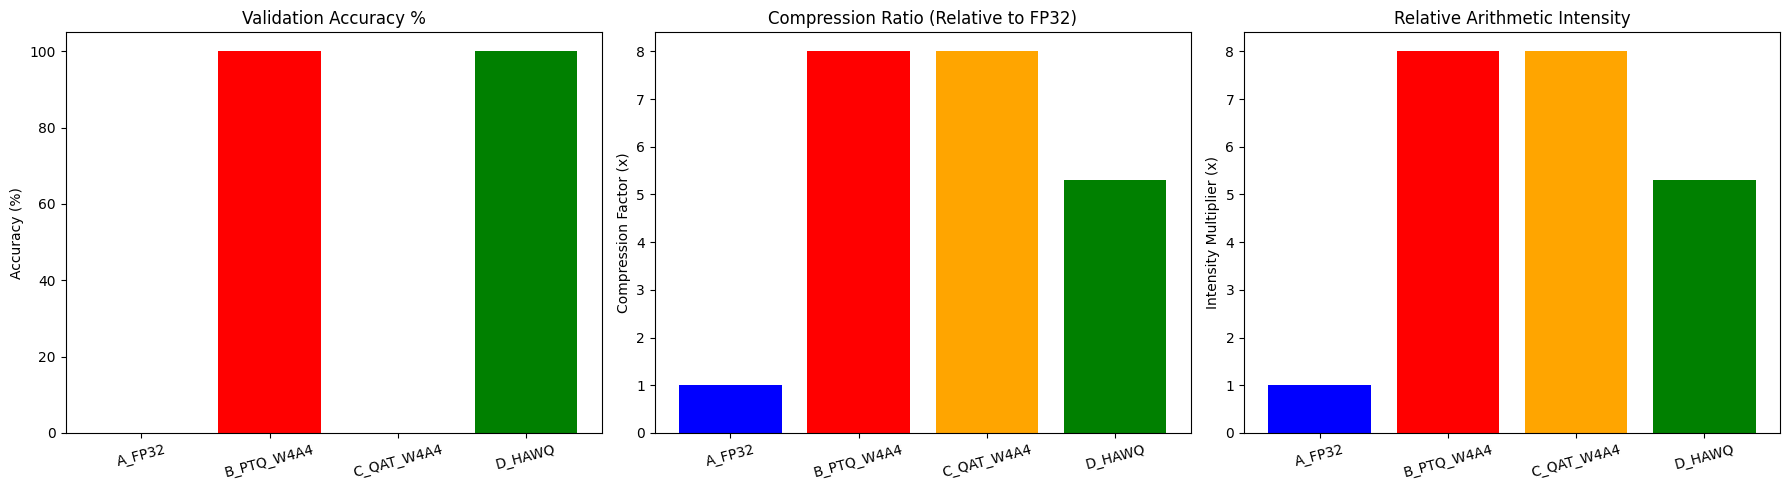


Experiment Summary:
A_FP32: Accuracy = 0.0000, Avg Bits = 32.00
B_PTQ_W4A4: Accuracy = 1.0000, Avg Bits = 4.00
C_QAT_W4A4: Accuracy = 0.0000, Avg Bits = 4.00
D_HAWQ: Accuracy = 1.0000, Avg Bits = 6.03


In [44]:
labels = list(results_log.keys())
accuracies = [results_log[k]["acc"] * 100 for k in labels]
avg_bits = [results_log[k]["avg_bits"] for k in labels]

#Compression Ratio (Baseline is 32-bit)
compression_ratios = [32.0 / b for b in avg_bits]
#Arithmetic Intensity relative to FP32 (AI scales linearly with CR for memory-bound layers)
arithmetic_intensities = [cr for cr in compression_ratios] 

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(labels, accuracies, color=['blue', 'red', 'orange', 'green'])
axes[0].set_title("Validation Accuracy %")
axes[0].set_ylabel("Accuracy (%)")
axes[0].tick_params(axis='x', rotation=15)

#Compression Ratio
axes[1].bar(labels, compression_ratios, color=['blue', 'red', 'orange', 'green'])
axes[1].set_title("Compression Ratio (Relative to FP32)")
axes[1].set_ylabel("Compression Factor (x)")
axes[1].tick_params(axis='x', rotation=15)

#Arithmetic Intensity
axes[2].bar(labels, arithmetic_intensities, color=['blue', 'red', 'orange', 'green'])
axes[2].set_title("Relative Arithmetic Intensity")
axes[2].set_ylabel("Intensity Multiplier (x)")
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("\nExperiment Summary:")
for k, v in results_log.items():
    print(f"{k}: Accuracy = {v['acc']:.4f}, Avg Bits = {v['avg_bits']:.2f}")